# MRP3SAT Reduction

A quick prototype in Python to assess the feasibility of our Unity project.

## Important Assessments

- validate MRP3SAT instances
- given a valid instance, find a valid drawing
- 

## How To Run

From `python-prototype/`:

```bash
source venv/bin/activate
pip install -r requirements.txt
jupyter notebook mrp3sat_reduction.ipynb
```

Or, without activating the venv:

```bash
venv/bin/python -m pip install -r requirements.txt
venv/bin/jupyter notebook mrp3sat_reduction.ipynb
```

In VS Code, select the interpreter/kernel from `python-prototype/venv` and run cells top to bottom.

In [1]:
from __future__ import annotations

import os
from collections import deque
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import yaml

%matplotlib inline

print("All OK!")

All OK!


## Validate Problem Instances

In [2]:
@dataclass(frozen=True)
class Clause:
    label: str
    variables: tuple[int, int, int]
    sign: str

    @property
    def left(self) -> int:
        return min(self.variables)

    @property
    def right(self) -> int:
        return max(self.variables)


@dataclass(frozen=True)
class Instance:
    n: int
    m: int
    positive: tuple[Clause, ...]
    negative: tuple[Clause, ...]

    @property
    def clauses(self) -> tuple[Clause, ...]:
        return self.positive + self.negative


class ValidationError(Exception):
    """Raised when the input is not a valid MRP3SAT instance."""


def load_instance(path: Path | str) -> Instance:
    path = Path(path)
    try:
        with path.open("r", encoding="utf-8") as handle:
            data = yaml.safe_load(handle)
    except FileNotFoundError as exc:
        raise ValidationError(f"Input file not found: {path}") from exc
    except yaml.YAMLError as exc:
        raise ValidationError(f"YAML parse error: {exc}") from exc

    return parse_instance_data(data)


def parse_instance_data(data: object) -> Instance:
    if not isinstance(data, dict):
        raise ValidationError("Top-level YAML value must be a mapping.")
    raw_instance = data.get("instance")
    if not isinstance(raw_instance, dict):
        raise ValidationError("Missing required mapping: instance.")

    n = _required_int(raw_instance, "n")
    m = _required_int(raw_instance, "m")
    if n <= 0:
        raise ValidationError("instance.n must be a positive integer.")
    if m < 0:
        raise ValidationError("instance.m must be a nonnegative integer.")

    raw_positive = _required_clause_list(raw_instance, "positive")
    raw_negative = _required_clause_list(raw_instance, "negative")
    if len(raw_positive) + len(raw_negative) != m:
        raise ValidationError(
            "instance.m must equal len(instance.positive) + len(instance.negative)."
        )

    positive = tuple(
        _parse_clause(raw_clause, f"C{index}", "positive", n)
        for index, raw_clause in enumerate(raw_positive, start=1)
    )
    negative = tuple(
        _parse_clause(raw_clause, f"C{index}", "negative", n)
        for index, raw_clause in enumerate(raw_negative, start=len(positive) + 1)
    )

    return Instance(n=n, m=m, positive=positive, negative=negative)


def _required_int(mapping: dict, key: str) -> int:
    value = mapping.get(key)
    if type(value) is not int:
        raise ValidationError(f"instance.{key} must be an integer.")
    return value


def _required_clause_list(mapping: dict, key: str) -> list:
    value = mapping.get(key)
    if not isinstance(value, list):
        raise ValidationError(f"instance.{key} must be a list of clauses.")
    return value


def _parse_clause(raw_clause: object, label: str, sign: str, n: int) -> Clause:
    if not isinstance(raw_clause, list):
        raise ValidationError(f"{label} must be a list of exactly 3 variable IDs.")
    if len(raw_clause) != 3:
        raise ValidationError(f"{label} must contain exactly 3 variables.")
    if any(type(variable) is not int for variable in raw_clause):
        raise ValidationError(f"{label} must contain only integer variable IDs.")

    variables = tuple(raw_clause)
    if len(set(variables)) != 3:
        raise ValidationError(f"{label} must contain 3 distinct variables.")
    out_of_range = [variable for variable in variables if variable < 1 or variable > n]
    if out_of_range:
        bad = ", ".join(str(variable) for variable in out_of_range)
        raise ValidationError(f"{label} contains variable IDs outside 1..{n}: {bad}.")

    return Clause(label=label, variables=variables, sign=sign)


def compute_clause_levels(clauses: Iterable[Clause], side_name: str) -> dict[str, int]:
    clauses = tuple(clauses)
    by_label = {clause.label: clause for clause in clauses}
    edges: dict[str, set[str]] = {clause.label: set() for clause in clauses}
    indegree = {clause.label: 0 for clause in clauses}

    for outer in clauses:
        outer_variables = set(outer.variables)
        for inner in clauses:
            if outer == inner:
                continue
            has_blocked_connection = any(
                outer.left < variable < outer.right and variable not in outer_variables
                for variable in inner.variables
            )
            if not has_blocked_connection:
                continue
            if outer.label not in edges[inner.label]:
                edges[inner.label].add(outer.label)
                indegree[outer.label] += 1

    queue = deque(
        sorted(
            (label for label, degree in indegree.items() if degree == 0),
            key=_label_number,
        )
    )
    order: list[str] = []
    while queue:
        label = queue.popleft()
        order.append(label)
        for neighbor in sorted(edges[label], key=_label_number):
            indegree[neighbor] -= 1
            if indegree[neighbor] == 0:
                queue.append(neighbor)

    if len(order) != len(clauses):
        cyclic = ", ".join(
            sorted((label for label, degree in indegree.items() if degree > 0), key=_label_number)
        )
        raise ValidationError(
            f"{side_name} clauses cannot be drawn without crossings; "
            f"ordering constraints contain a cycle involving: {cyclic}."
        )

    return {label: level for level, label in enumerate(order, start=1) if label in by_label}


def _label_number(label: str) -> int:
    return int(label[1:])


def validate_instance(instance: Instance) -> tuple[dict[str, int], dict[str, int]]:
    positive_levels = compute_clause_levels(instance.positive, "Positive")
    negative_levels = compute_clause_levels(instance.negative, "Negative")
    return positive_levels, negative_levels


def summarize_instance(instance: Instance) -> None:
    print(
        f"Valid MRP3SAT instance: {instance.n} variables, "
        f"{instance.m} clauses ({len(instance.positive)} positive, "
        f"{len(instance.negative)} negative)."
    )
    for clause in instance.clauses:
        literal_prefix = "" if clause.sign == "positive" else "not "
        literals = ", ".join(f"{literal_prefix}x{variable}" for variable in clause.variables)
        print(f"{clause.label}: {literals}")

In [3]:
input_path = Path("input.yaml")
if not input_path.exists():
    input_path = Path("python-prototype/input.yaml")

instance = load_instance(input_path)
positive_levels, negative_levels = validate_instance(instance)
summarize_instance(instance)
print("Positive levels:", positive_levels)
print("Negative levels:", negative_levels)

Valid MRP3SAT instance: 4 variables, 4 clauses (2 positive, 2 negative).
C1: x1, x2, x4
C2: x2, x3, x4
C3: not x1, not x2, not x3
C4: not x1, not x3, not x4
Positive levels: {'C2': 1, 'C1': 2}
Negative levels: {'C3': 1, 'C4': 2}


## Find a valid drawing

In [14]:
# CONSTANTS
_BOX_H = 0.36
_GAP = 1  # integer units between variable boxes
_XAXIS_COLOUR = "#32cd32"


In [15]:
def _build_queues(clauses: Iterable[Clause], levels: dict[str, int]) -> dict[int, list[Clause]]:
    '''
    I came up with this greedy algorithm! Why is it formally correct? Idk, intuition.
    (Claude wrote the code though)
    -- farms4life2016
    '''
    clauses = tuple(clauses)
    sorted_clauses = sorted(clauses, key=lambda c: (levels[c.label], _label_number(c.label)))

    all_vars: set[int] = set()
    for clause in clauses:
        all_vars.update(clause.variables)

    lefty:  dict[int, list[Clause]] = {v: [] for v in all_vars}
    middle: dict[int, list[Clause]] = {v: [] for v in all_vars}
    righty: dict[int, list[Clause]] = {v: [] for v in all_vars}

    for clause in sorted_clauses:
        L, M, R = sorted(clause.variables)
        righty[L].insert(0, clause)
        middle[M].append(clause)
        lefty[R].append(clause)

    return {v: lefty[v] + middle[v] + righty[v] for v in all_vars}


def _positions_from_queues(
    queues: dict[int, list[Clause]],
    x_start: dict[int, int],
) -> dict[tuple[str, int], int]:
    positions: dict[tuple[str, int], int] = {}
    for v, q in queues.items():
        for index, clause in enumerate(q):
            positions[(clause.label, v)] = x_start[v] + index
    return positions


def compute_layout(
    instance: Instance,
    positive_levels: dict[str, int],
    negative_levels: dict[str, int],
) -> tuple[dict[int, int], dict[int, int], dict[tuple[str, int], int], dict[tuple[str, int], int]]:
    pos_queues = _build_queues(instance.positive, positive_levels)
    neg_queues = _build_queues(instance.negative, negative_levels)

    width: dict[int, int] = {
        v: max(1, len(pos_queues.get(v, [])), len(neg_queues.get(v, [])))
        for v in range(1, instance.n + 1)
    }

    x_start: dict[int, int] = {}
    cursor = 0
    for v in range(1, instance.n + 1):
        x_start[v] = cursor
        cursor += width[v] + _GAP

    pos_cx = _positions_from_queues(pos_queues, x_start)
    neg_cx = _positions_from_queues(neg_queues, x_start)

    return x_start, width, pos_cx, neg_cx

def _draw_side(
    axis,
    clauses: Iterable[Clause],
    levels: dict[str, int],
    connector_x: dict[tuple[str, int], int],
    direction: int,
    color: str,
    y_scale: float = 1.0
) -> None:
    for clause in clauses:
        y = direction * y_scale * levels[clause.label]
        xs = [connector_x[(clause.label, v)] for v in clause.variables]
        axis.plot([min(xs), max(xs)], [y, y], color=color, linewidth=2.4)
        y_root = direction * _BOX_H / 2
        for v in sorted(clause.variables):
            x = connector_x[(clause.label, v)]
            axis.plot([x, x], [y_root, y], color=color, linewidth=1.2, alpha=0.8)
            axis.scatter([x], [y], color=color, s=18, zorder=3)
        label_y = y + 0.16 * direction
        va = "bottom" if direction > 0 else "top"
        axis.text(
            (min(xs) + max(xs)) / 2, label_y, clause.label,
            ha="center", va=va, fontsize=10, color=color, fontweight="bold",
        )

def draw_instance(
    instance: Instance,
    positive_levels: dict[str, int],
    negative_levels: dict[str, int],
    output: Path | str | None = None,
):
    x_start, width, pos_cx, neg_cx = compute_layout(instance, positive_levels, negative_levels)

    max_positive = max(positive_levels.values(), default=0)
    max_negative = max(negative_levels.values(), default=0)
    total_x = max(x_start[v] + width[v] for v in range(1, instance.n + 1))

    fig_width = max(7.0, total_x * 0.5)
    fig_height = max(4.5, (max_positive + max_negative + 2) * 0.9)
    fig, axis = plt.subplots(figsize=(fig_width, fig_height))

    # x-axis
    axis.axhline(0, color=_XAXIS_COLOUR, linewidth=1.2, zorder=1)

    for v in range(1, instance.n + 1):
        bx = x_start[v] - 0.4
        bw = width[v] - 1 + 0.8   # connector columns are 0..width-1; pad ±0.4
        box = FancyBboxPatch(
            (bx, -_BOX_H / 2), bw, _BOX_H,
            boxstyle="round,pad=0.02",
            linewidth=1.2, edgecolor="#222222", facecolor="white", zorder=5,
        )
        axis.add_patch(box)
        axis.text(
            bx + bw / 2, 0, f"x{v}",
            ha="center", va="center", fontsize=9, zorder=6,
        )

    _draw_side(axis, instance.positive, positive_levels, pos_cx, direction=1,  color="#2166ac")
    _draw_side(axis, instance.negative, negative_levels, neg_cx, direction=-1, color="#b2182b")

    axis.set_aspect("equal", adjustable="box")
    axis.set_xlim(-0.5, total_x + 0.5)
    axis.set_ylim(-(max_negative + 1), max_positive + 1)
    axis.set_xticks(range(total_x + 1))
    axis.set_yticks(range(-(max_negative + 1), max_positive + 2))
    axis.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    axis.grid(True, color="#aaaaaa", linewidth=0.6, linestyle="--", zorder=0)
    axis.set_title("Square-Grid-Aligned Monotone Rectilinear Planar 3SAT")
    for spine in axis.spines.values():
        spine.set_visible(False)
    fig.tight_layout()

    if output is not None:
        output = Path(output)
        fig.savefig(output, bbox_inches="tight")
        print(f"Saved drawing to {output}")

    return fig, axis



(<Figure size 700x540 with 1 Axes>,
 <Axes: title={'center': 'Square-Grid-Aligned Monotone Rectilinear Planar 3SAT'}>)

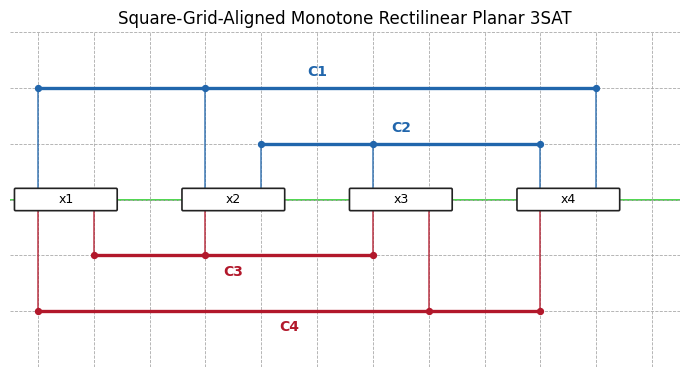

In [16]:
draw_instance(instance, positive_levels, negative_levels)

## Simple Transformations

In [17]:
import math

# MORE CONSTANTS
_SQRT3 = math.sqrt(3)
_GRID_STEP = _SQRT3 / 2


In [22]:
def compute_layout_alternating(
    instance: Instance,
    positive_levels: dict[str, int],
    negative_levels: dict[str, int],
) -> tuple[dict[int, int], dict[int, int], dict[tuple[str, int], int], dict[tuple[str, int], int]]:
    pos_queues = _build_queues(instance.positive, positive_levels)
    neg_queues = _build_queues(instance.negative, negative_levels)

    # Each variable gets paired (up, down) slots; width = 2 * max occupancy
    slot_count: dict[int, int] = {
        v: max(1, len(pos_queues.get(v, [])), len(neg_queues.get(v, [])))
        for v in range(1, instance.n + 1)
    }
    width: dict[int, int] = {v: 2 * slot_count[v] for v in range(1, instance.n + 1)}

    x_start: dict[int, int] = {}
    cursor = 0
    for v in range(1, instance.n + 1):
        x_start[v] = cursor
        cursor += width[v] + _GAP

    # Even columns go up (positive), odd columns go down (negative)
    pos_cx: dict[tuple[str, int], int] = {}
    for v, q in pos_queues.items():
        for i, clause in enumerate(q):
            pos_cx[(clause.label, v)] = x_start[v] + 2 * i

    neg_cx: dict[tuple[str, int], int] = {}
    for v, q in neg_queues.items():
        for i, clause in enumerate(q):
            neg_cx[(clause.label, v)] = x_start[v] + 2 * i + 1

    return x_start, width, pos_cx, neg_cx


def _fmt_sqrt3_half(k: int) -> str:
    """Format k * (√3/2) as a mathtext label."""
    if k == 0:
        return r"$0$"
    sign = "-" if k < 0 else ""
    a = abs(k)
    if a % 2 == 0:
        m = a // 2
        base = r"\sqrt{3}" if m == 1 else rf"{m}\sqrt{{3}}"
    else:
        base = r"\frac{\sqrt{3}}{2}" if a == 1 else rf"\frac{{{a}\sqrt{{3}}}}{{2}}"
    return rf"${sign}{base}$"


def draw_instance_alternating(
    instance: Instance,
    positive_levels: dict[str, int],
    negative_levels: dict[str, int],
    output: Path | str | None = None,
):
    x_start_alt, width_alt, pos_cx_alt, neg_cx_alt = compute_layout_alternating(
        instance, positive_levels, negative_levels
    )

    max_positive = max(positive_levels.values(), default=0)
    max_negative = max(negative_levels.values(), default=0)
    total_x_alt = max(x_start_alt[v] + width_alt[v] for v in range(1, instance.n + 1))

    k_min = -(2 * max_negative + 1)
    k_max =   2 * max_positive  + 1
    y_bot = k_min * _GRID_STEP
    y_top = k_max * _GRID_STEP

    fig_width = max(7.0, total_x_alt * 0.5)
    fig_height = max(4.5, (y_top - y_bot) * 0.9)
    fig, axis = plt.subplots(figsize=(fig_width, fig_height))

    axis.axhline(0, color=_XAXIS_COLOUR, linewidth=1.2, zorder=1)

    for v in range(1, instance.n + 1):
        bx = x_start_alt[v] - 0.4
        bw = width_alt[v] - 1 + 0.8
        box = FancyBboxPatch(
            (bx, -_BOX_H / 2), bw, _BOX_H,
            boxstyle="round,pad=0.02",
            linewidth=1.2, edgecolor="#222222", facecolor="white", zorder=5,
        )
        axis.add_patch(box)
        axis.text(bx + bw / 2, 0, f"x{v}", ha="center", va="center", fontsize=9, zorder=6)

    _draw_side(axis, instance.positive, positive_levels, pos_cx_alt, direction=1,  color="#2166ac", y_scale=_SQRT3)
    _draw_side(axis, instance.negative, negative_levels, neg_cx_alt, direction=-1, color="#b2182b", y_scale=_SQRT3)

    axis.set_aspect("equal", adjustable="box")
    axis.set_xlim(-0.5, total_x_alt + 0.5)
    axis.set_ylim(y_bot, y_top)

    # x: integer gridlines, no labels
    axis.set_xticks(range(total_x_alt + 1))
    axis.tick_params(axis="x", bottom=False, labelbottom=False)

    # left y-axis: every √3/2
    ytick_positions = [k * _GRID_STEP for k in range(k_min, k_max + 1)]
    ytick_labels    = [_fmt_sqrt3_half(k) for k in range(k_min, k_max + 1)]
    axis.set_yticks(ytick_positions)
    axis.set_yticklabels(ytick_labels, fontsize=7)
    axis.tick_params(axis="y", left=False, length=0, labelleft=True)
    axis.grid(True, color="#aaaaaa", linewidth=0.6, linestyle="--", zorder=0)

    axis.set_title(r"Alternating $\sqrt{3}$-Grid-Aligned Monotone Rectilinear Planar 3SAT")
    for spine in axis.spines.values():
        spine.set_visible(False)
    fig.tight_layout()

    if output is not None:
        output = Path(output)
        fig.savefig(output, bbox_inches="tight")
        print(f"Saved drawing to {output}")

    return fig, axis

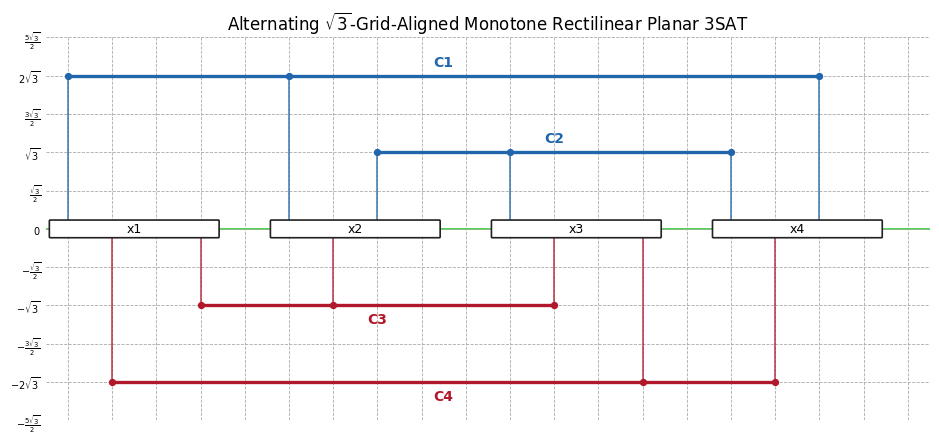

In [23]:
fig_alt, axis_alt = draw_instance_alternating(instance, positive_levels, negative_levels)
plt.show()